# K-Means on Cyberbullying Tweets: `age` vs `not_cyberbullying`

**Goal:** apply K-Means (k=2) to tweet text and see whether the two clusters it finds
line up with the two real categories.

**Key idea to remember:** K-Means is *unsupervised*. It never looks at the labels
(`age=1`, `not_cyberbullying=0`) while clustering. We keep the labels only to *check*
the clusters afterward.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 1. Load the data

In [2]:
df = pd.read_csv('cyberbullying_tweets.csv')
print('Full dataset shape:', df.shape)
print(df['cyberbullying_type'].value_counts())
df.head()

Full dataset shape: (47692, 2)
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


## 2. Keep only the two classes we care about

We drop `religion`, `ethnicity`, and `gender`. Only `age` and `not_cyberbullying` remain.

In [3]:
df = df[df['cyberbullying_type'].isin(['age', 'not_cyberbullying'])].copy()
print('After filtering to two classes:', df.shape)
print(df['cyberbullying_type'].value_counts())

After filtering to two classes: (15937, 2)
cyberbullying_type
age                  7992
not_cyberbullying    7945
Name: count, dtype: int64


## 3. Remove duplicate rows

In [4]:
before = df.shape[0]
df = df.drop_duplicates()
print(f'Removed {before - df.shape[0]} duplicate rows. Now: {df.shape[0]} rows')

Removed 8 duplicate rows. Now: 15929 rows


## 4. Label the classes

`age -> 1`, `not_cyberbullying -> 0`. This column is used **only for evaluation later**,
not for training K-Means.

In [5]:
df['label'] = df['cyberbullying_type'].map({'age': 1, 'not_cyberbullying': 0})
df[['tweet_text', 'cyberbullying_type', 'label']].head()

,tweet_text,cyberbullying_type,label
0,"In other words #katandandre, your food was cra...",not_cyberbullying,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0


## 5. Clean the tweet text

Lowercase, and strip URLs, @mentions, #hashtag symbols, and punctuation. Cleaner tokens
give the vectorizer better signal.

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'@\w+', ' ', text)                # @mentions
    text = re.sub(r'#', ' ', text)                   # keep hashtag word, drop the #
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()         # collapse whitespace
    return text

df['clean_text'] = df['tweet_text'].apply(clean_text)
df[['tweet_text', 'clean_text']].head()

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,a classy whore or more red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",meh p thanks for the heads up but not too conc...
4,@RudhoeEnglish This is an ISIS account pretend...,this is an isis account pretending to be a kur...


## 6. Turn text into numbers (TF-IDF)

K-Means needs numeric vectors. TF-IDF gives each tweet a vector where words that are
frequent in a tweet but rare across all tweets get higher weight.

In [7]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
print('TF-IDF matrix shape (tweets x features):', X.shape)

TF-IDF matrix shape (tweets x features): (15929, 5000)


## 7. Run K-Means with k=2 (two groups)

In [8]:
kmeans = KMeans(n_clusters=2, random_state=23, n_init=10)
df['cluster'] = kmeans.fit_predict(X)
print('Points per cluster:')
print(df['cluster'].value_counts())

Points per cluster:
cluster
0    11466
1     4463
Name: count, dtype: int64


## 8. Reduce to 2D with PCA (for plotting only)

The TF-IDF matrix has thousands of dimensions, so we can't plot it directly.
PCA projects it down to 2 dimensions just so we can *see* it.

In [9]:
pca = PCA(n_components=2, random_state=23)
X_2d = pca.fit_transform(X.toarray())
print('2D shape for plotting:', X_2d.shape)

2D shape for plotting: (15929, 2)


## 9. Visualize: clusters found vs. true labels

Left = the two groups K-Means found (unsupervised).
Right = the real categories. If they look similar, the clustering matched reality.

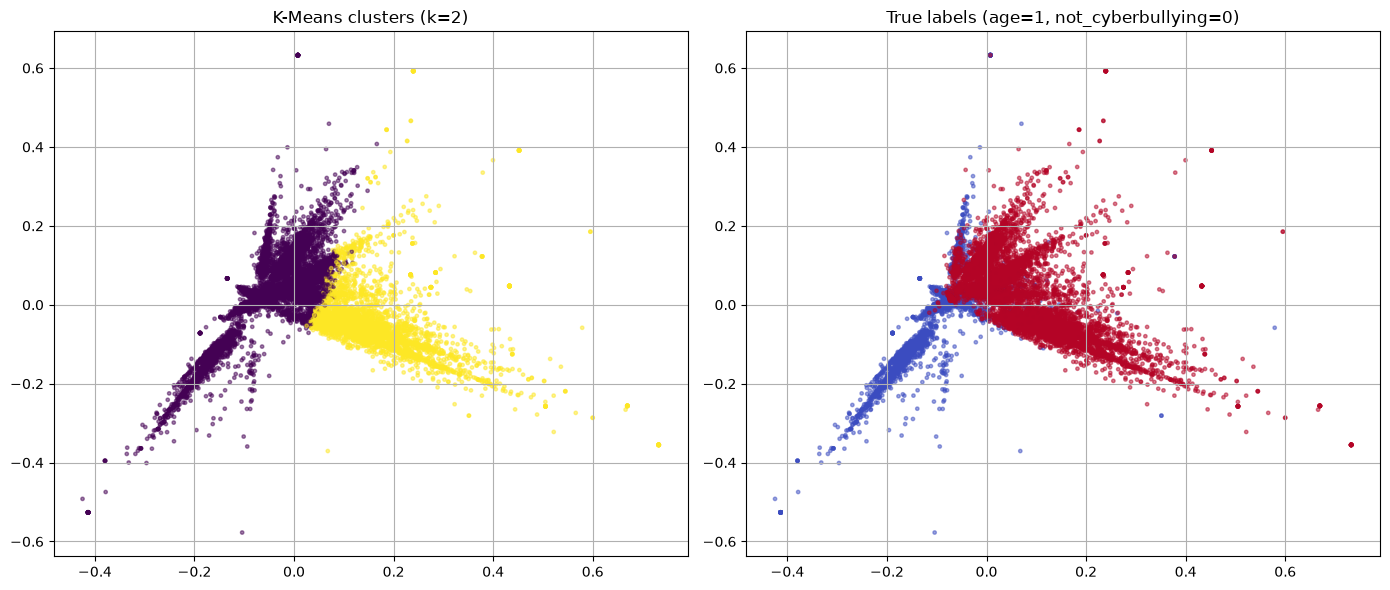

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'], cmap='viridis', s=6, alpha=0.5)
axes[0].set_title('K-Means clusters (k=2)')
axes[0].grid(True)

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=df['label'], cmap='coolwarm', s=6, alpha=0.5)
axes[1].set_title('True labels (age=1, not_cyberbullying=0)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 10. How well did the clusters match the labels?

K-Means numbers its clusters arbitrarily, so cluster `0` might correspond to label `1`.
We try both alignments and take the best agreement.

In [11]:
agreement = (df['cluster'] == df['label']).mean()
best_match = max(agreement, 1 - agreement)
print(f'Cluster-vs-label agreement: {best_match:.2%}')

print('\nCross-tab (rows = true label, cols = cluster):')
print(pd.crosstab(df['label'], df['cluster']))

Cluster-vs-label agreement: 77.12%

Cross-tab (rows = true label, cols = cluster):
cluster     0     1
label              
0        7879    58
1        3587  4405
